# Preparación de Datos y EDA - Evaluaciones Agropecuarias Municipales (EVA)
Este cuaderno contiene el proceso de unificación, limpieza y Análisis Exploratorio de Datos de los históricos agrícolas de Colombia. El dataset resultante será exportado para su almacenamiento en la nube e ingesta en los modelos de Machine Learning.

### Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None) # Para visualizar todas las columnas

### Carga de Datos

In [ ]:
print("Cargando datasets históricos...")

# Se cambia la codificación a latin-1 para procesar correctamente las tildes y eñes
df_07_18 = pd.read_csv('eva_2007_2018.csv', sep=';', encoding='latin-1')
df_19_24 = pd.read_csv('eva_2019_2024.csv', sep=';', encoding='latin-1')

print("Carga completada exitosamente.")

Cargando datasets históricos...
Carga completada exitosamente.


### Inspección Inicial de los Datasets (Antes de la Homologación)

In [6]:
def inspect_dataset(df, name):
    print(f"{"="*40}")
    print(f"INSPECCIÓN DEL DATASET: {name}")
    print(f"{"="*40}")
    print(f"1. Dimensiones (Filas, Columnas): {df.shape}\n")
    print("2. Tipos de Datos y Valores Nulos:")
    # Creamos un DataFrame resumen para mejor lectura
    resume = pd.DataFrame({
        'Tipo de Dato': df.dtypes,
        'Valores Nulos': df.isnull().sum(),
        '% de Nulos': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(resume)
    print("\n3. Muestra de los datos (primeras 3 filas):")
    display(df.head(3))
    print("\n")

inspect_dataset(df_07_18, "EVA 2007 - 2018")
inspect_dataset(df_19_24, "EVA 2019 - 2024")

INSPECCIÓN DEL DATASET: EVA 2007 - 2018
1. Dimensiones (Filas, Columnas): (210847, 17)

2. Tipos de Datos y Valores Nulos:
                                              Tipo de Dato  Valores Nulos  \
CÓD.DEP.                                             int64              0   
DEPARTAMENTO                                        object              0   
CÓD. MUN.                                            int64              0   
MUNICIPIO                                           object              0   
GRUPO DE CULTIVO                                    object              0   
SUBGRUPO DE CULTIVO                                 object              0   
CULTIVO                                             object              0   
DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO       object              0   
AÑO                                                  int64              0   
PERIODO                                             object              0   
Área Sembrada (ha)            

,CÓD.DEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO DE CULTIVO,SUBGRUPO DE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada (ha),Área Cosechada (ha),Producción (t),Rendimiento (t/ha),ESTADO FISICO PRODUCCION,NOMBRE CIENTIFICO,CICLO DE CULTIVO
0,15,BOYACA,15114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,2,1,1,1,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,82,80,1440,18,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,"1,5","1,5",26,"17,33333333",FRUTO FRESCO,BETA VULGARIS,TRANSITORIO




INSPECCIÓN DEL DATASET: EVA 2019 - 2024
1. Dimensiones (Filas, Columnas): (141073, 18)

2. Tipos de Datos y Valores Nulos:
                              Tipo de Dato  Valores Nulos  % de Nulos
Código Dane departamento             int64              0         0.0
Departamento                        object              0         0.0
Código Dane municipio                int64              0         0.0
Municipio                           object              0         0.0
Desagregación cultivo               object              0         0.0
Cultivo                             object              0         0.0
Ciclo del cultivo                   object              0         0.0
Grupo cultivo                       object              0         0.0
Subgrupo                            object              0         0.0
Año                                  int64              0         0.0
Periodo                             object              0         0.0
Área sembrada (ha)                 

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Desagregación cultivo,Cultivo,Ciclo del cultivo,Grupo cultivo,Subgrupo,Año,Periodo,Área sembrada (ha),Área cosechada (ha),Producción (t),Rendimiento (t/ha),Nombre científico del cultivo,Código del cultivo,Estado físico del cultivo
0,5,Antioquia,5001,Medellín,Aguacate demás variedades,Aguacate,Permanente,Frutales,Demás frutales,2019,2019,24,23,138,6,Persea americana,2040299,En fresco
1,5,Antioquia,5001,Medellín,Aguacate demás variedades,Aguacate,Permanente,Frutales,Demás frutales,2020,2020,"8,52","3,52","21,12",6,Persea americana,2040299,En fresco
2,5,Antioquia,5001,Medellín,Aguacate demás variedades,Aguacate,Permanente,Frutales,Demás frutales,2021,2021,"8,52","4,52","27,12",6,Persea americana,2040299,En fresco


### Homologación y Unificación

In [7]:
# Diccionarios de mapeo para estandarizar nombres
rename_07_18 = {
    'CÓD.DEP.': 'cod_dep', 'DEPARTAMENTO': 'departamento',
    'CÓD. MUN.': 'cod_mun', 'MUNICIPIO': 'municipio',
    'GRUPO DE CULTIVO': 'grupo_cultivo', 'SUBGRUPO DE CULTIVO': 'subgrupo_cultivo',
    'CULTIVO': 'cultivo', 'DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO': 'desagregacion_cultivo',
    'AÑO': 'anio', 'PERIODO': 'periodo',
    'Área Sembrada (ha)': 'area_sembrada_ha', 'Área Cosechada (ha)': 'area_cosechada_ha',
    'Producción (t)': 'produccion_t', 'Rendimiento (t/ha)': 'rendimiento_t_ha',
    'ESTADO FISICO PRODUCCION': 'estado_fisico', 'NOMBRE CIENTIFICO': 'nombre_cientifico',
    'CICLO DE CULTIVO': 'ciclo_cultivo'
}

rename_19_24 = {
    'Código Dane departamento': 'cod_dep', 'Departamento': 'departamento',
    'Código Dane municipio': 'cod_mun', 'Municipio': 'municipio',
    'Desagregación cultivo': 'desagregacion_cultivo', 'Cultivo': 'cultivo',
    'Ciclo del cultivo': 'ciclo_cultivo', 'Grupo cultivo': 'grupo_cultivo',
    'Subgrupo': 'subgrupo_cultivo', 'Año': 'anio', 'Periodo': 'periodo',
    'Área sembrada (ha)': 'area_sembrada_ha', 'Área cosechada (ha)': 'area_cosechada_ha',
    'Producción (t)': 'produccion_t', 'Rendimiento (t/ha)': 'rendimiento_t_ha',
    'Nombre científico del cultivo': 'nombre_cientifico', 'Estado físico del cultivo': 'estado_fisico',
    'Código del cultivo': 'cod_cultivo'
}

# Aplicar renombramiento
df_07_18.rename(columns=rename_07_18, inplace=True)
df_19_24.rename(columns=rename_19_24, inplace=True)

# Concatenar ambos DataFrames
df = pd.concat([df_07_18, df_19_24], ignore_index=True)

# Eliminar 'cod_cultivo' porque tiene un 100% de nulos en el histórico antiguo
df.drop('cod_cultivo', axis=1, inplace=True, errors='ignore')

### Limpieza e Imputación de Datos

In [8]:
print("Iniciando limpieza de texto y conversión numérica...")

# 1. Estandarización de variables categóricas (mayúsculas y sin espacios extra)
string_cols = ['departamento', 'municipio', 'grupo_cultivo', 'subgrupo_cultivo', 'cultivo', 'desagregacion_cultivo', 'estado_fisico', 'nombre_cientifico', 'ciclo_cultivo']
for col in string_cols:
    df[col] = df[col].astype(str).str.upper().str.strip()

# 2. Conversión Numérica (Reemplazar comas por puntos en decimales si vienen como texto)
num_cols = ['area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'rendimiento_t_ha']
for col in num_cols:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# 3. Imputación analítica: Recalcular rendimiento donde sea nulo
df['rendimiento_t_ha'] = np.where(df['area_cosechada_ha'] > 0, 
                                  df['produccion_t'] / df['area_cosechada_ha'], 
                                  0)

print("Limpieza finalizada.")

Iniciando limpieza de texto y conversión numérica...
Limpieza finalizada.


### Inspección del Dataset Final (Limpio y Unificado)

In [9]:
print(f"{"="*40}")
print("INSPECCIÓN DEL DATASET FINAL UNIFICADO")
print(f"{"="*40}")
print(f"1. Dimensiones Finales: {df.shape}\n")

print("2. Resumen de Columnas y Nulos:")
resume_final = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    '% de Nulos': (df.isnull().sum() / len(df) * 100).round(4)
})
display(resume_final)

print("\n3. Estadísticas Descriptivas de las Variables Numéricas:")
display(df.describe().round(2))

print("\n4. Muestra aleatoria de 5 registros:")
display(df.sample(5))

INSPECCIÓN DEL DATASET FINAL UNIFICADO
1. Dimensiones Finales: (351920, 17)

2. Resumen de Columnas y Nulos:


,Tipo de Dato,Valores Nulos,% de Nulos
cod_dep,int64,0,0.0
departamento,object,0,0.0
cod_mun,int64,0,0.0
municipio,object,0,0.0
grupo_cultivo,object,0,0.0
subgrupo_cultivo,object,0,0.0
cultivo,object,0,0.0
desagregacion_cultivo,object,0,0.0
anio,int64,0,0.0
periodo,object,0,0.0



3. Estadísticas Descriptivas de las Variables Numéricas:


,cod_dep,cod_mun,anio,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha
count,351920.00,351920.00,351920.00,351920.00,351920.00,351920.00,351920.00
mean,39.91,40334.57,2016.21,263.77,231.63,2910.50,9.70
std,25.18,25158.82,5.32,1147.31,1026.61,45971.51,15.13
min,5.00,5001.00,2006.00,0.00,0.00,0.00,0.00
25%,17.00,17444.00,2012.00,8.00,6.00,27.00,1.50
50%,41.00,41298.00,2017.00,28.50,23.00,121.94,5.50
75%,66.00,66456.00,2021.00,125.20,106.00,600.00,12.00
max,99.00,99773.00,2024.00,60000.00,61000.00,4776340.50,253.00



4. Muestra aleatoria de 5 registros:


,cod_dep,departamento,cod_mun,municipio,grupo_cultivo,subgrupo_cultivo,cultivo,desagregacion_cultivo,anio,periodo,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha,estado_fisico,nombre_cientifico,ciclo_cultivo
84700,52,NARIÑO,52207,CONSACA,LEGUMINOSAS,FRIJOL,FRIJOL,FRIJOL ARBUSTIVO,2016,2016A,450.0,341.0,350.00,1.026393,GRANO SECO,PHASEOLUS VULGARIS,TRANSITORIO
147026,70,SUCRE,70708,SAN MARCOS,TUBERCULOS Y PLATANOS,ÑAME,ÑAME,ÑAME,2012,2012,75.0,75.0,600.00,8.000000,TUBERCULO FRESCO,DIOSCOREA VILLOSA,ANUAL
118610,5,ANTIOQUIA,5315,GUADALUPE,CEREALES,MAIZ,MAIZ,MAIZ TRADICIONAL,2010,2010B,3.0,3.0,5.40,1.800000,GRANO SECO,ZEA MAYS,TRANSITORIO
182490,13,BOLIVAR,13780,TALAIGUA NUEVO,OTROS PERMANENTES,TABACO,TABACO NEGRO,TABACO NEGRO,2014,2014,25.0,22.0,33.00,1.500000,HOJA SECA,NICOTIANA SPP.,ANUAL
334169,73,TOLIMA,73283,FRESNO,LEGUMINOSAS,LEGUMINOSAS,FRIJOL,FRIJOL,2020,2020B,685.0,670.0,1356.64,2.024836,GRANO SECO,PHASEOLUS VULGARIS,TRANSITORIO


### Exportación a CSV

In [10]:
# Exportar para ingesta en Cloud
output_file = 'dataset_eva_unificado_limpio.csv'
df.to_csv(output_file, index=False, sep=';', encoding='utf-8')
print(f"Dataset exportado exitosamente como {output_file} listo para tu pipeline en la nube.")

Dataset exportado exitosamente como dataset_eva_unificado_limpio.csv listo para tu pipeline en la nube.


## Análisis Exploratorio de Datos (EDA)

A continuación exploraremos la distribución de las variables numéricas, las relaciones entre ellas y el comportamiento de las variables categóricas. Esto nos ayudará a identificar *outliers* y entender las dinámicas agrícolas por región.

### EDA - Distribución y Correlación Numérica

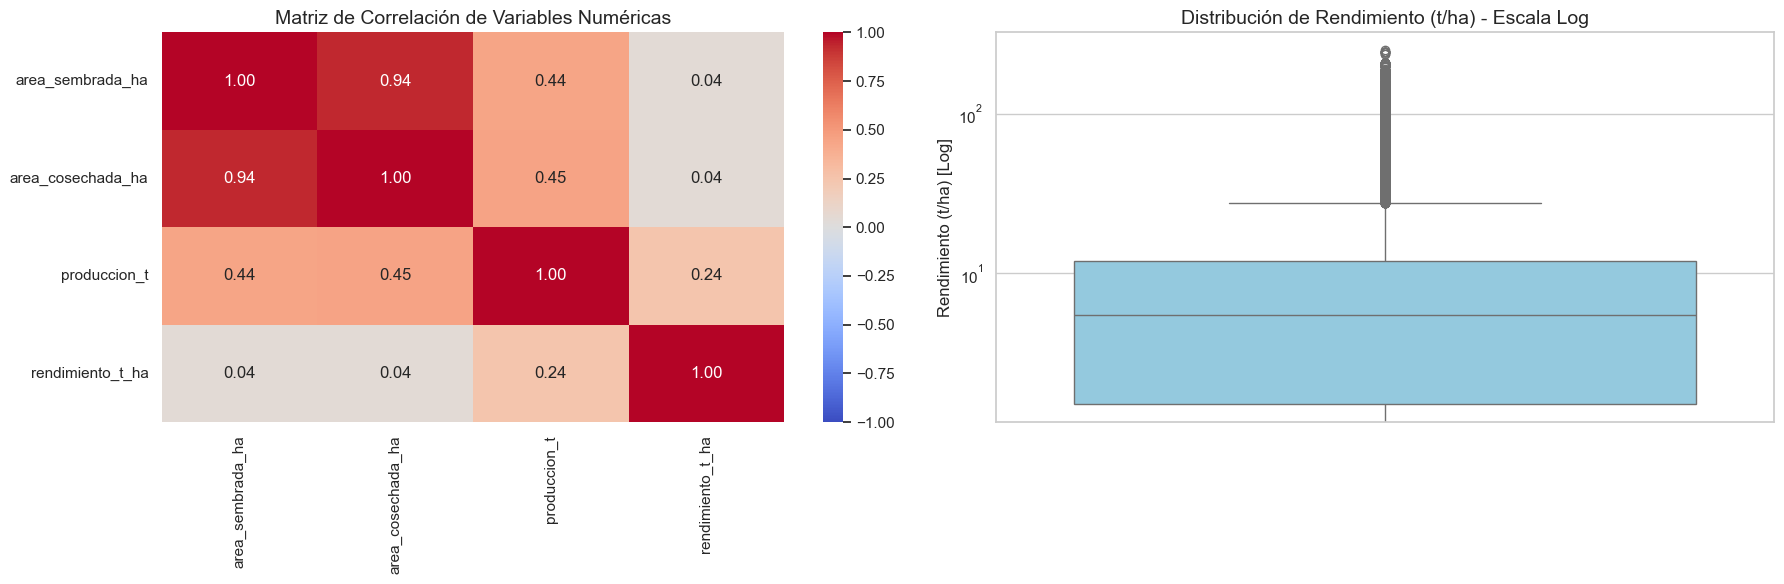

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Matriz de Correlación
corr_matrix = df[['area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'rendimiento_t_ha']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Matriz de Correlación de Variables Numéricas', fontsize=14)

# 2. Boxplot de Rendimiento (para detectar outliers en el target predictivo)
# Usamos escala logarítmica por la alta varianza en los rendimientos agrícolas
sns.boxplot(y=df['rendimiento_t_ha'], ax=axes[1], color='skyblue')
axes[1].set_yscale('log')
axes[1].set_title('Distribución de Rendimiento (t/ha) - Escala Log', fontsize=14)
axes[1].set_ylabel('Rendimiento (t/ha) [Log]')

plt.tight_layout()
plt.show()

### EDA - Análisis Geográfico (Departamentos)

C:\Users\PC\AppData\Local\Temp\ipykernel_22592\466029231.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_deptos.values, y=top_deptos.index, palette='magma')


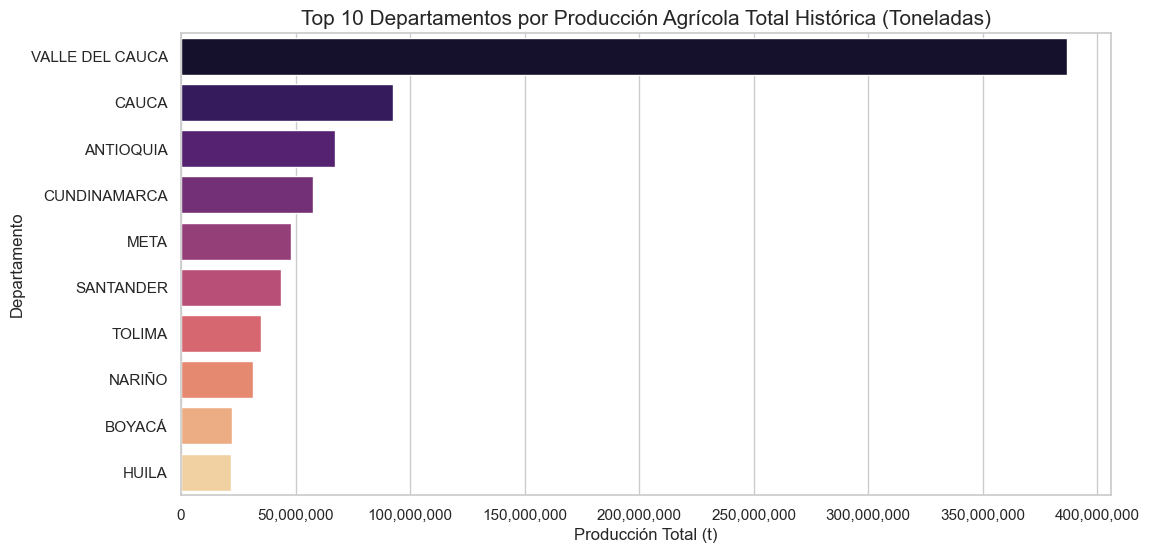

In [12]:
# Top 10 Departamentos con mayor Producción Total Histórica
top_deptos = df.groupby('departamento')['produccion_t'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_deptos.values, y=top_deptos.index, palette='magma')
plt.title('Top 10 Departamentos por Producción Agrícola Total Histórica (Toneladas)', fontsize=15)
plt.xlabel('Producción Total (t)')
plt.ylabel('Departamento')

# Formatear el eje X para leer millones fácilmente
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.show()

### EDA - Análisis por Cultivo y Ciclo

C:\Users\PC\AppData\Local\Temp\ipykernel_22592\3618426428.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cultivos.values, y=top_cultivos.index, palette='viridis', ax=axes[0])


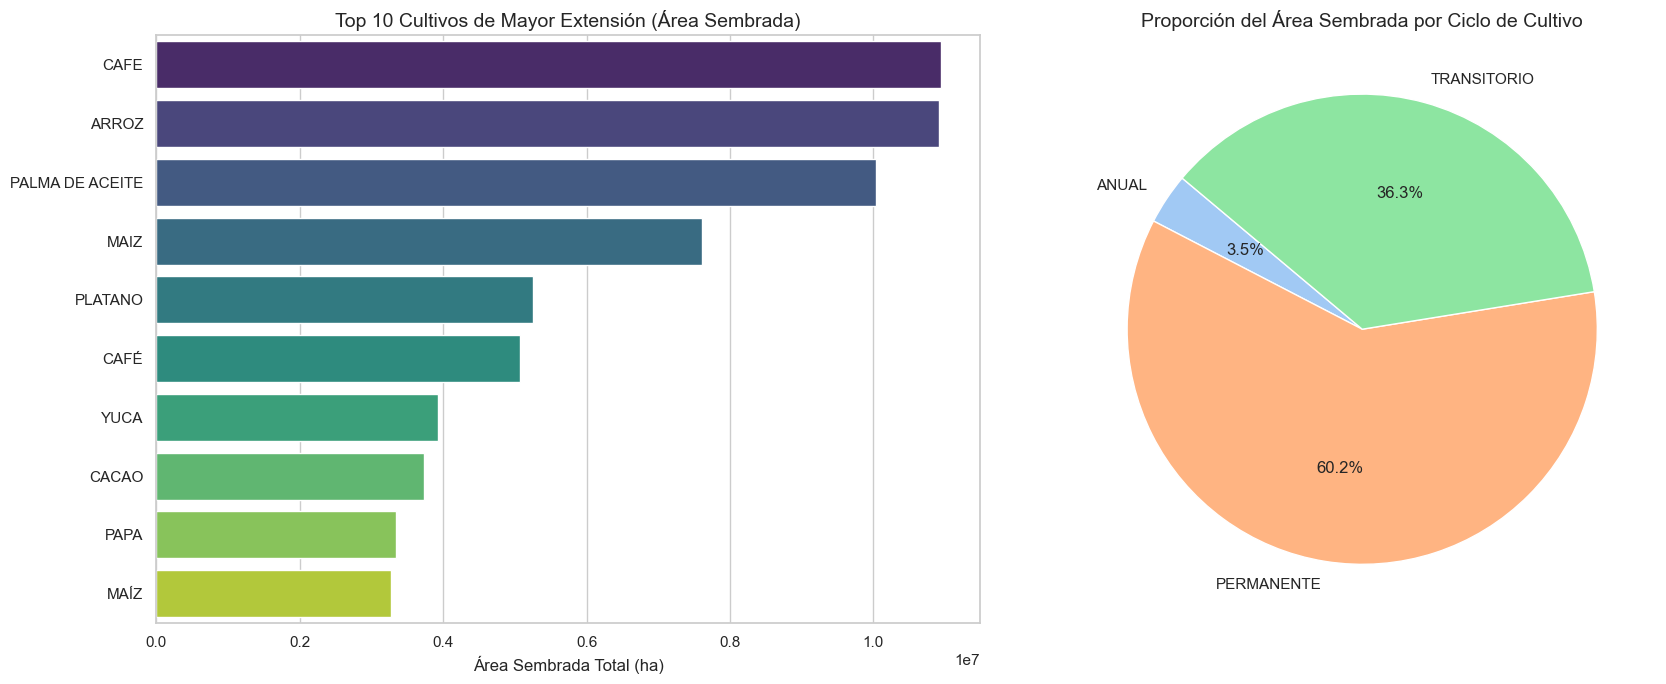

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Top 10 Cultivos por Área Sembrada
top_cultivos = df.groupby('cultivo')['area_sembrada_ha'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cultivos.values, y=top_cultivos.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Cultivos de Mayor Extensión (Área Sembrada)', fontsize=14)
axes[0].set_xlabel('Área Sembrada Total (ha)')
axes[0].set_ylabel('')

# 2. Proporción de Área Sembrada por Ciclo de Cultivo
ciclos = df.groupby('ciclo_cultivo')['area_sembrada_ha'].sum()
axes[1].pie(ciclos.values, labels=ciclos.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1].set_title('Proporción del Área Sembrada por Ciclo de Cultivo', fontsize=14)

plt.tight_layout()
plt.show()

### EDA - Evolución Temporal (Series de Tiempo)

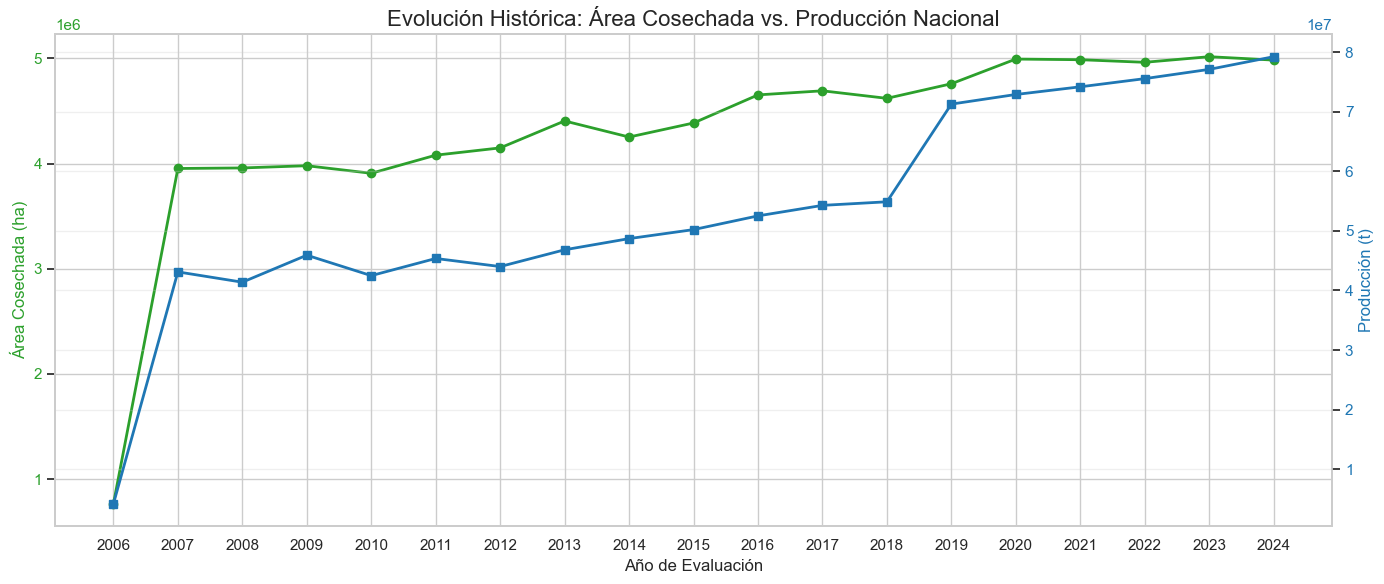

In [14]:
# Evolución anual del área cosechada vs producción
evolucion_anual = df.groupby('anio')[['area_cosechada_ha', 'produccion_t']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('Año de Evaluación', fontsize=12)
ax1.set_ylabel('Área Cosechada (ha)', color='tab:green', fontsize=12)
ax1.plot(evolucion_anual['anio'], evolucion_anual['area_cosechada_ha'], color='tab:green', marker='o', linewidth=2, label='Área Cosechada')
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.set_xticks(evolucion_anual['anio'].unique()) # Mostrar todos los años

ax2 = ax1.twinx()  
ax2.set_ylabel('Producción (t)', color='tab:blue', fontsize=12)
ax2.plot(evolucion_anual['anio'], evolucion_anual['produccion_t'], color='tab:blue', marker='s', linewidth=2, label='Producción')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Evolución Histórica: Área Cosechada vs. Producción Nacional', fontsize=16)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()